In [1]:
import pywt
import numpy as np
from scipy.signal import find_peaks
import matplotlib.pyplot as plt
import h5py
import os

In [4]:
data_path = "../../UCI/data"
FS = 125
WINDOW_SIZE = 1000

In [5]:
recordings = []

for part in range(1,5):

    file_path = f"{data_path}/Part_{part}.mat"

    f = h5py.File(file_path, "r")

    dataset = f[f"Part_{part}"]


    for i in range(dataset.shape[0]):

        recordings.append(
            (f, dataset[i,0])
        )


print("Total recordings:", len(recordings))

Total recordings: 12000


In [18]:
# Get the file handle and HDF5 reference
file_handle, recording_ref = recordings[250]

# Dereference the HDF5 reference
recording = file_handle[recording_ref]

print(type(recording))
print("Shape:", recording.shape)
print("Dtype:", recording.dtype)

<class 'h5py._hl.dataset.Dataset'>
Shape: (71000, 3)
Dtype: float64


In [19]:
def wavelet_denoise_db8(
    ppg,
    wavelet="db8",
    level=7
):

    ppg = np.asarray(
        ppg,
        dtype=np.float64
    )

    # -----------------------------------------
    # Check signal
    # -----------------------------------------

    if len(ppg) < 2:
        return None

    if not np.all(
        np.isfinite(ppg)
    ):
        return None

    # -----------------------------------------
    # DWT decomposition
    # -----------------------------------------

    coeffs = pywt.wavedec(
        ppg,
        wavelet=wavelet,
        level=level
    )

    # coeffs structure:
    #
    # [A10, D10, D9, ..., D2, D1]
    #
    # A10 = lowest-frequency approximation
    # D1  = highest-frequency detail

    # -----------------------------------------
    # Remove the lowest-frequency
    # approximation component
    #
    # This removes very slow baseline
    # variation.
    # -----------------------------------------

    coeffs[0] = np.zeros_like(
        coeffs[0]
    )

    # -----------------------------------------
    # Reconstruct signal
    # -----------------------------------------

    denoised = pywt.waverec(
        coeffs,
        wavelet=wavelet
    )

    # waverec can return slightly more samples
    # because of boundary handling.
    
    denoised = denoised[
        :len(ppg)
    ]

    return denoised.astype(
        np.float32
    )

In [20]:
def analyze_wavelet_denoising(
    ppg,
    denoised_ppg,
    fs=125,
    plot_seconds=30
):
    """
    Compare original and wavelet-denoised PPG.

    Parameters
    ----------
    ppg : array-like
        Original PPG signal.

    denoised_ppg : array-like
        Wavelet-denoised PPG signal.

    fs : int
        Sampling frequency in Hz.

    plot_seconds : int or float
        Duration of signal to show in the first plot.

    Returns
    -------
    results : dict
        Dictionary containing comparison statistics.
    """

    # ==================================================
    # Convert to numpy arrays
    # ==================================================

    ppg = np.asarray(ppg).squeeze()
    denoised_ppg = np.asarray(denoised_ppg).squeeze()


    # ==================================================
    # Check shapes
    # ==================================================

    if ppg.shape != denoised_ppg.shape:

        raise ValueError(
            f"Shape mismatch: "
            f"PPG {ppg.shape} vs "
            f"Denoised {denoised_ppg.shape}"
        )


    # ==================================================
    # Basic statistics
    # ==================================================

    original_mean = np.mean(ppg)
    original_std = np.std(ppg)
    original_min = np.min(ppg)
    original_max = np.max(ppg)

    denoised_mean = np.mean(denoised_ppg)
    denoised_std = np.std(denoised_ppg)
    denoised_min = np.min(denoised_ppg)
    denoised_max = np.max(denoised_ppg)


    # ==================================================
    # Removed component
    # ==================================================

    removed_component = (
        ppg - denoised_ppg
    )


    # ==================================================
    # Correlation
    # ==================================================

    correlation = np.corrcoef(
        ppg,
        denoised_ppg
    )[0, 1]


    # ==================================================
    # Residual statistics
    #
    # Remove mean first so that the DC/baseline
    # difference does not dominate the residual.
    # ==================================================

    ppg_centered = (
        ppg - original_mean
    )

    denoised_centered = (
        denoised_ppg - denoised_mean
    )

    residual = (
        ppg_centered -
        denoised_centered
    )

    residual_std = np.std(
        residual
    )

    residual_ratio = (
        residual_std /
        original_std
    )


    # ==================================================
    # Print results
    # ==================================================

    print("=" * 50)
    print("WAVELET DENOISING ANALYSIS")
    print("=" * 50)

    print("\nShape:")
    print("Original shape :", ppg.shape)
    print("Denoised shape :", denoised_ppg.shape)

    print("\nOriginal:")
    print(
        f"Mean : {original_mean:.6f}"
    )
    print(
        f"Std  : {original_std:.6f}"
    )
    print(
        f"Min  : {original_min:.6f}"
    )
    print(
        f"Max  : {original_max:.6f}"
    )

    print("\nDenoised:")
    print(
        f"Mean : {denoised_mean:.6f}"
    )
    print(
        f"Std  : {denoised_std:.6f}"
    )
    print(
        f"Min  : {denoised_min:.6f}"
    )
    print(
        f"Max  : {denoised_max:.6f}"
    )

    print("\nSimilarity:")
    print(
        f"Correlation : {correlation:.5f}"
    )

    print("\nResidual:")
    print(
        f"Residual std : {residual_std:.6f}"
    )
    print(
        f"Residual / signal std : "
        f"{residual_ratio * 100:.3f}%"
    )


    # ==================================================
    # Plot 1: Original vs denoised
    # ==================================================

    N = min(
        int(plot_seconds * fs),
        len(ppg)
    )

    plt.figure(
        figsize=(15, 5)
    )

    plt.plot(
        ppg[:N],
        label="Original PPG",
        alpha=0.7
    )

    plt.plot(
        denoised_ppg[:N],
        label="Denoised PPG",
        linewidth=1.5
    )

    plt.xlabel(
        "Sample"
    )

    plt.ylabel(
        "Amplitude"
    )

    plt.title(
        "Original vs db8 Wavelet-Denoised PPG"
    )

    plt.legend()

    plt.grid(
        alpha=0.3
    )

    plt.show()


    # ==================================================
    # Plot 2: Removed component
    # ==================================================

    plt.figure(
        figsize=(15, 4)
    )

    plt.plot(
        removed_component
    )

    plt.xlabel(
        "Sample"
    )

    plt.ylabel(
        "Amplitude"
    )

    plt.title(
        "Component Removed by Wavelet Denoising"
    )

    plt.grid(
        alpha=0.3
    )

    plt.show()


    # ==================================================
    # Plot 3: Centered residual
    # ==================================================

    plt.figure(
        figsize=(15, 4)
    )

    plt.plot(
        residual
    )

    plt.xlabel(
        "Sample"
    )

    plt.ylabel(
        "Amplitude"
    )

    plt.title(
        "Wavelet Residual After Removing DC Offset"
    )

    plt.grid(
        alpha=0.3
    )

    plt.show()


    # ==================================================
    # Return results
    # ==================================================

    results = {

        "original_mean":
            original_mean,

        "original_std":
            original_std,

        "original_min":
            original_min,

        "original_max":
            original_max,

        "denoised_mean":
            denoised_mean,

        "denoised_std":
            denoised_std,

        "denoised_min":
            denoised_min,

        "denoised_max":
            denoised_max,

        "correlation":
            correlation,

        "residual_std":
            residual_std,

        "residual_ratio":
            residual_ratio
    }

    return results

In [21]:
def plot_dwt_levels(ppg, wavelet="db8", level=7, fs=125):
    """
    Decomposes a PPG signal using DWT and plots every level
    (A_level, D_level, ..., D1) as stacked subplots, so you can
    visually inspect which layer holds baseline drift, which
    holds the pulse waveform, and which is just noise.
    """
 
    ppg = np.asarray(ppg, dtype=np.float64)
 
    coeffs = pywt.wavedec(ppg, wavelet=wavelet, level=level)
    # coeffs = [A_level, D_level, D_(level-1), ..., D1]
 
    labels = [f"A{level}"] + [f"D{j}" for j in range(level, 0, -1)]
 
    # approximate frequency band each layer represents (Hz)
    bands = []
    bands.append((0, fs / 2**(level + 1)))  # A_level band
    for j in range(level, 0, -1):
        low = fs / 2**(j + 1)
        high = fs / 2**j
        bands.append((low, high))
 
    n_plots = len(coeffs) + 1
    fig, axes = plt.subplots(n_plots, 1, figsize=(12, 2 * n_plots), sharex=False)
 
    # original signal on top
    axes[0].plot(ppg, color="black", linewidth=0.8)
    axes[0].set_title("Original PPG signal")
 
    for ax, c, label, (lo, hi) in zip(axes[1:], coeffs, labels, bands):
        ax.plot(c, linewidth=0.8)
        ax.set_title(f"{label}  |  ~{lo:.3f}-{hi:.3f} Hz  |  n={len(c)}")
 
    plt.tight_layout()
    plt.savefig("dwt_levels.png", dpi=150)
    plt.show()
 
    return coeffs
 

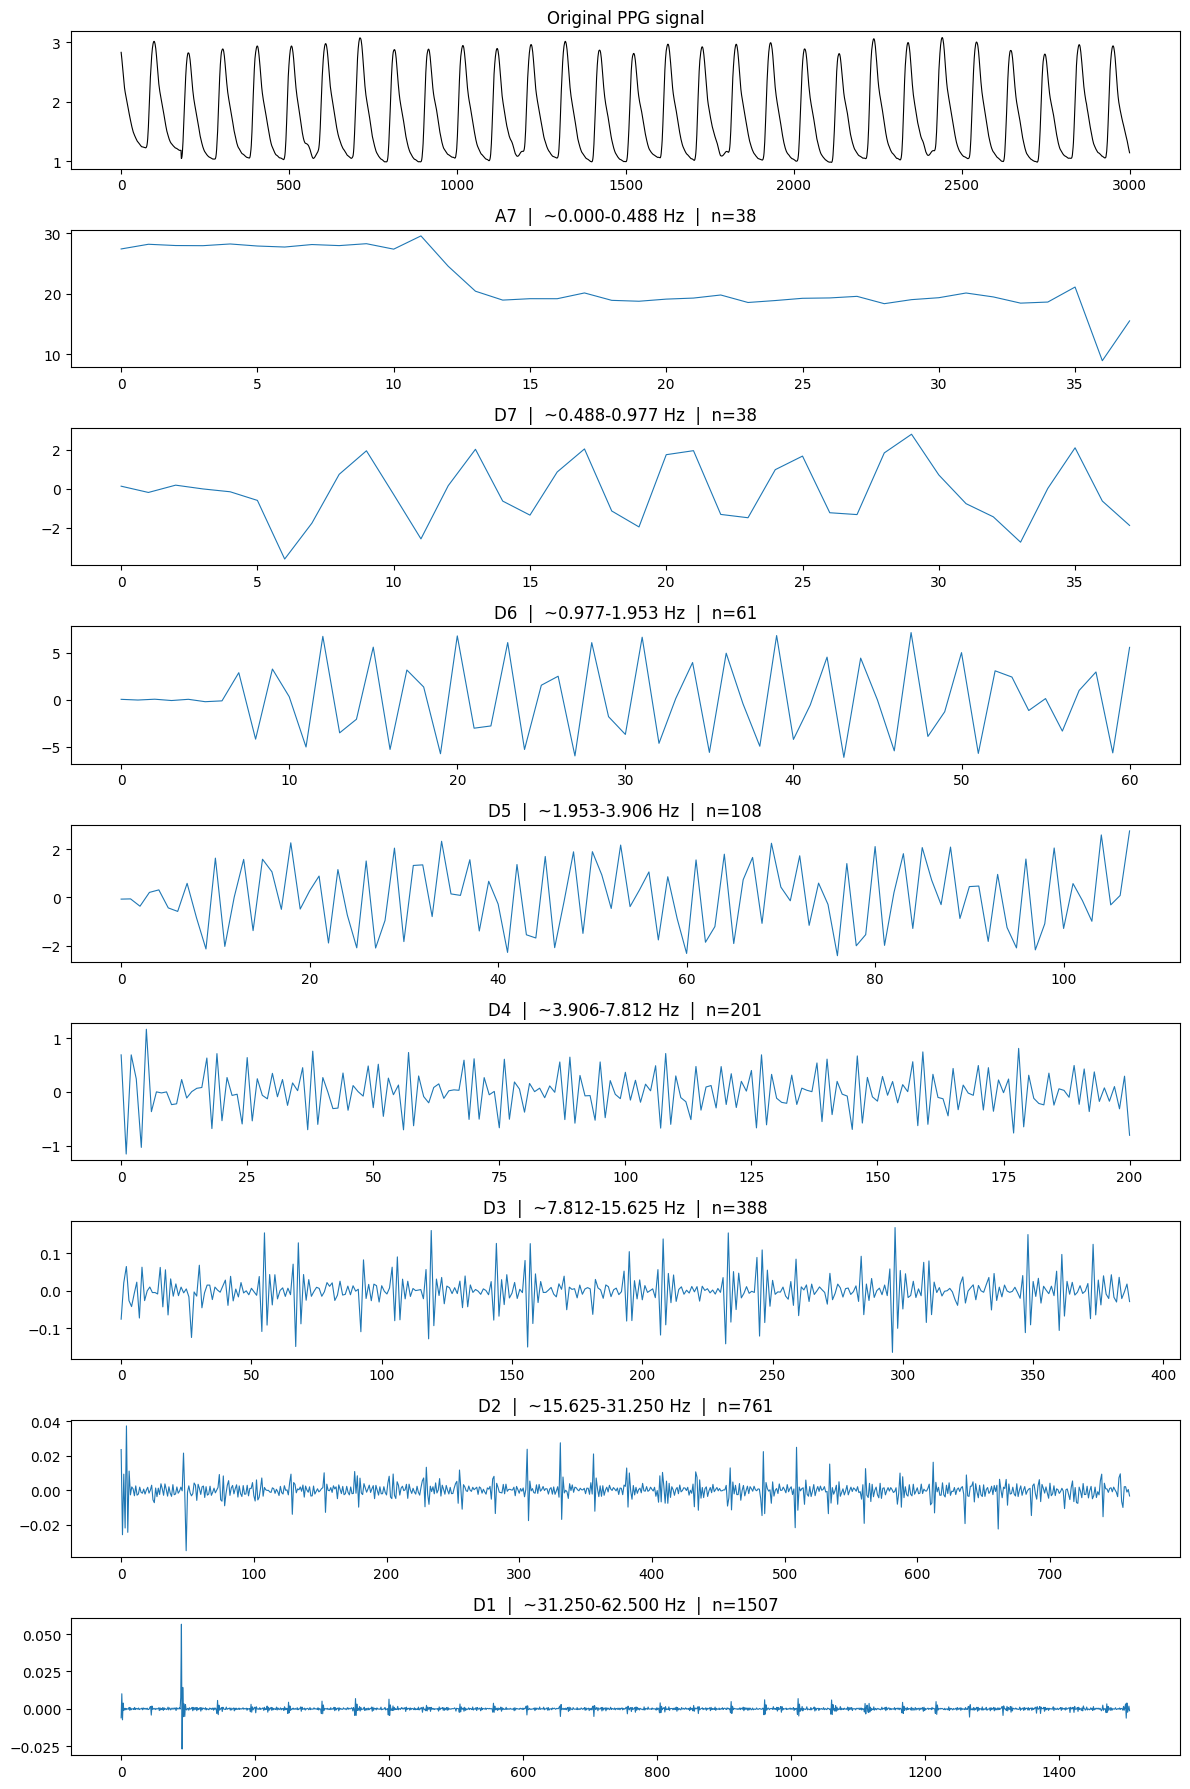

[array([27.43438194, 28.21203023, 28.00142012, 27.97729519, 28.26024914,
        27.92062328, 27.75411992, 28.1663475 , 27.99056592, 28.30532128,
        27.40249067, 29.59747608, 24.57154316, 20.43237972, 18.95919826,
        19.19291319, 19.18779022, 20.14483183, 18.91801082, 18.76926343,
        19.12189769, 19.29592932, 19.80501738, 18.56358796, 18.88569024,
        19.25775335, 19.31857293, 19.57983348, 18.36604323, 19.03554647,
        19.35470458, 20.13462287, 19.48509667, 18.45610561, 18.63573064,
        21.1222548 ,  8.9152933 , 15.51370979]),
 array([ 0.12323683, -0.1983354 ,  0.1763082 , -0.01739138, -0.16354701,
        -0.6066555 , -3.61501354, -1.77153062,  0.73208065,  1.93917921,
        -0.30467445, -2.58086723,  0.14722657,  2.01638409, -0.64133106,
        -1.36167207,  0.85367338,  2.03426626, -1.14945952, -1.96770617,
         1.73950794,  1.94569452, -1.32558532, -1.49580813,  0.97108412,
         1.66756082, -1.23903914, -1.33378024,  1.83165133,  2.7889375 ,
  

In [22]:
ppg = recording[:3000, 0]
plot_dwt_levels(ppg, wavelet="db8", level=7, fs=125)

WAVELET DENOISING ANALYSIS

Shape:
Original shape : (71000,)
Denoised shape : (71000,)

Original:
Mean : 1.710811
Std  : 0.643414
Min  : 0.000000
Max  : 3.874878

Denoised:
Mean : -0.000264
Std  : 0.638997
Min  : -1.524395
Max  : 2.047313

Similarity:
Correlation : 0.99301

Residual:
Residual std : 0.075916
Residual / signal std : 11.799%


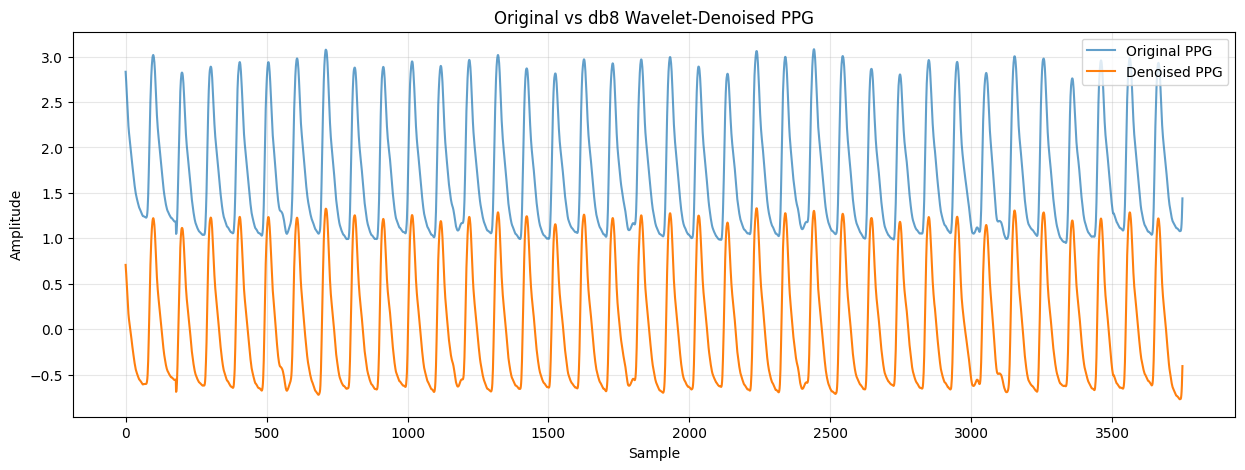

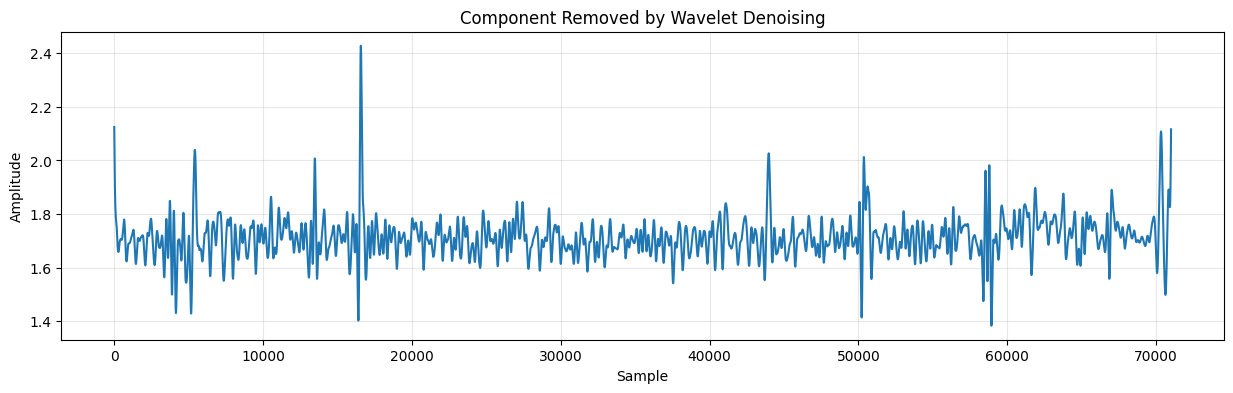

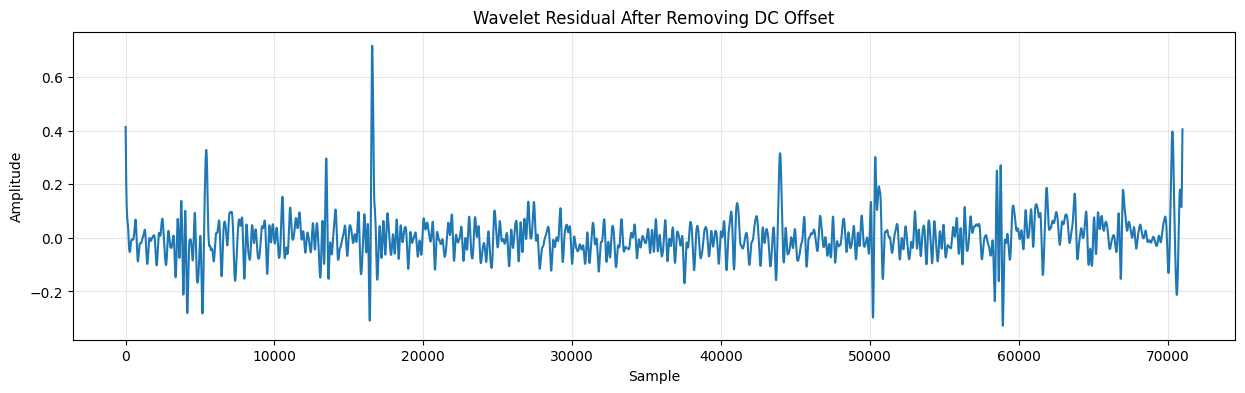

In [24]:
ppg = recording[:, 0]

denoised_ppg = wavelet_denoise_db8(
    ppg,
    wavelet="db8",
    level=7
)

results = analyze_wavelet_denoising(
    ppg,
    denoised_ppg,
    fs=125,
    plot_seconds=30
)

In [ ]:
ppg = recording[:, 0]

denoised_ppg = wavelet_denoise_db8(
    ppg,
    wavelet="db8",
    level=9
)

WAVELET DENOISING ANALYSIS

Shape:
Original shape : (71000,)
Denoised shape : (71000,)

Original:
Mean : 1.710811
Std  : 0.643414
Min  : 0.000000
Max  : 3.874878

Denoised:
Mean : -0.000264
Std  : 0.638997
Min  : -1.524395
Max  : 2.047313

Similarity:
Correlation : 0.99301

Residual:
Residual std : 0.075916
Residual / signal std : 11.799%


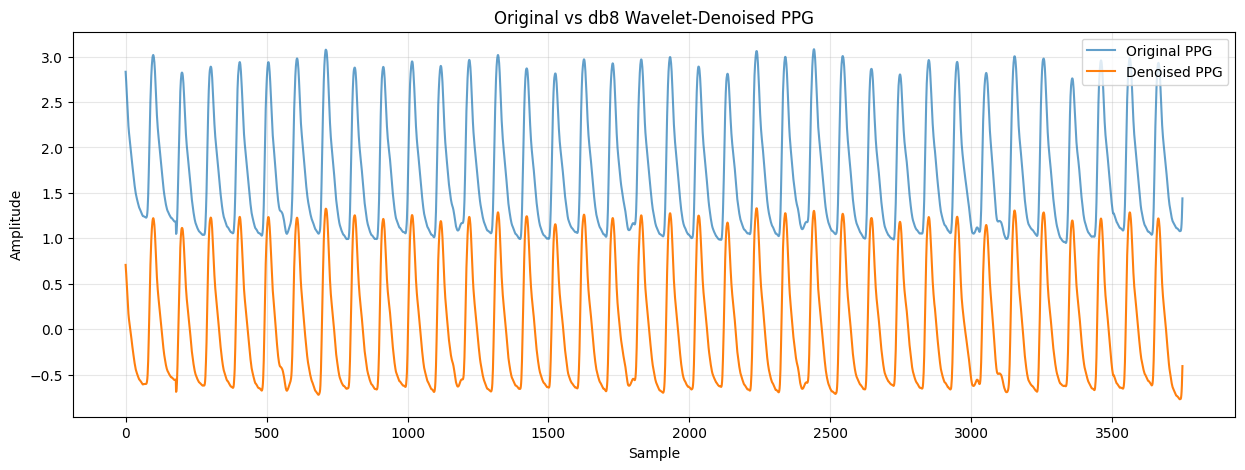

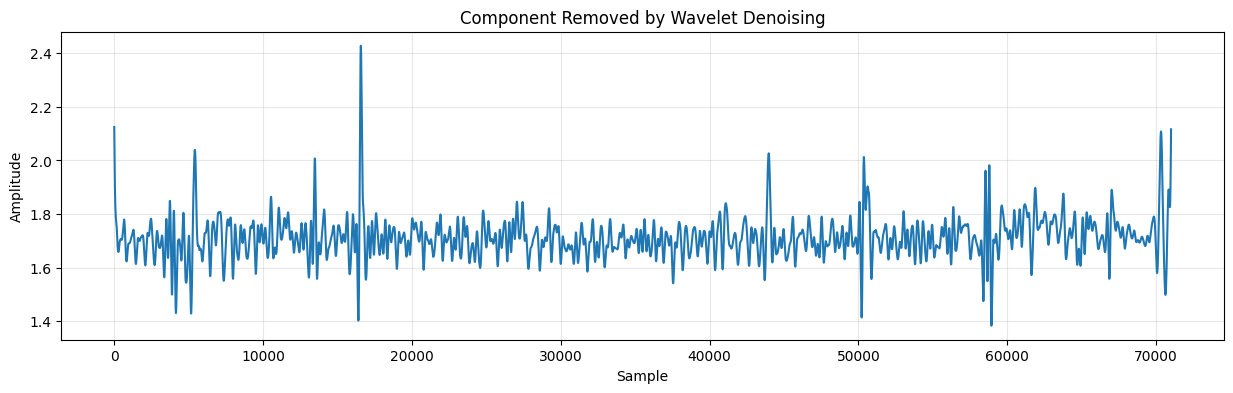

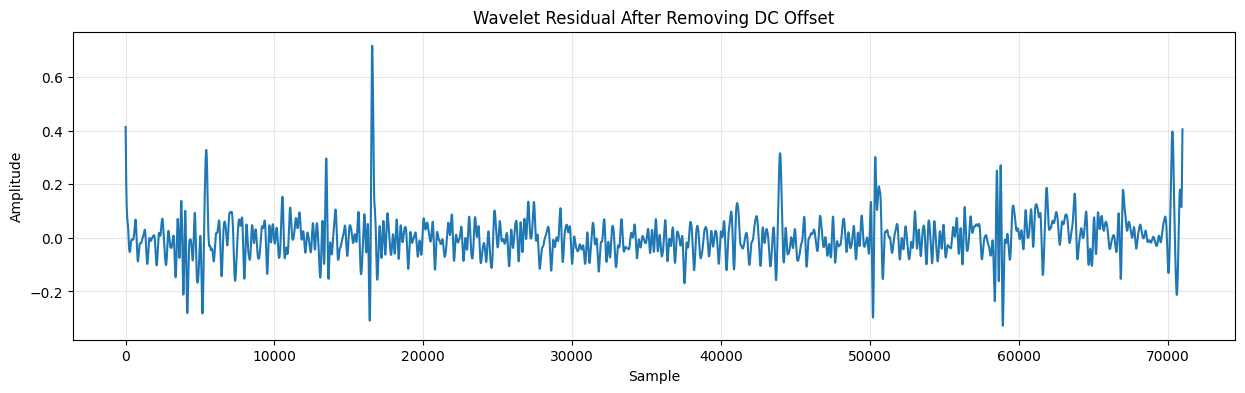

In [29]:
results = analyze_wavelet_denoising(
    ppg,
    denoised_ppg,
    fs=125,
    plot_seconds=30
)

WAVELET DENOISING ANALYSIS

Shape:
Original shape : (6000,)
Denoised shape : (6000,)

Original:
Mean : 1.521038
Std  : 0.633912
Min  : 0.944282
Max  : 3.191593

Denoised:
Mean : -0.002565
Std  : 0.634724
Min  : -0.859126
Max  : 1.693463

Similarity:
Correlation : 0.99613

Residual:
Residual std : 0.055787
Residual / signal std : 8.800%


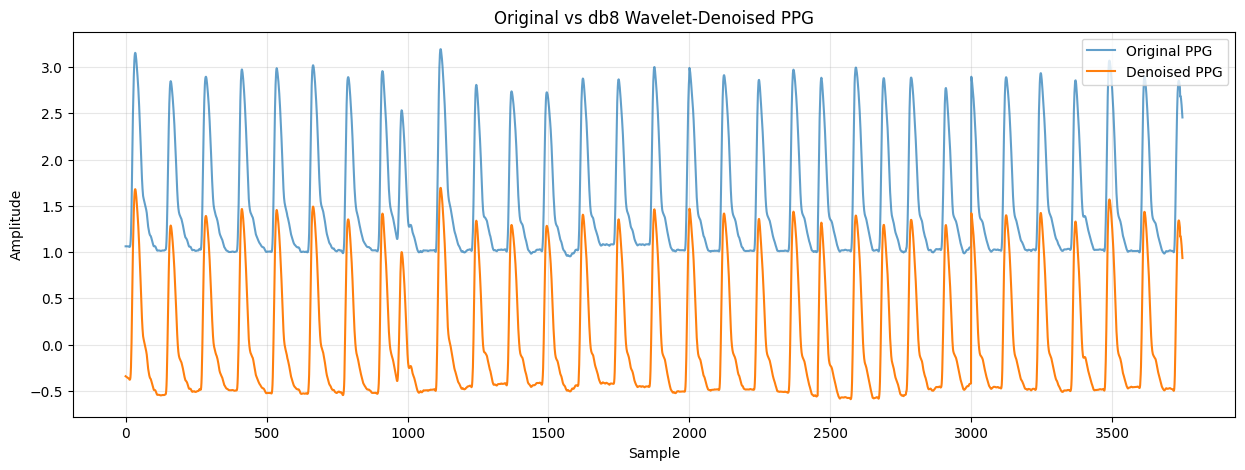

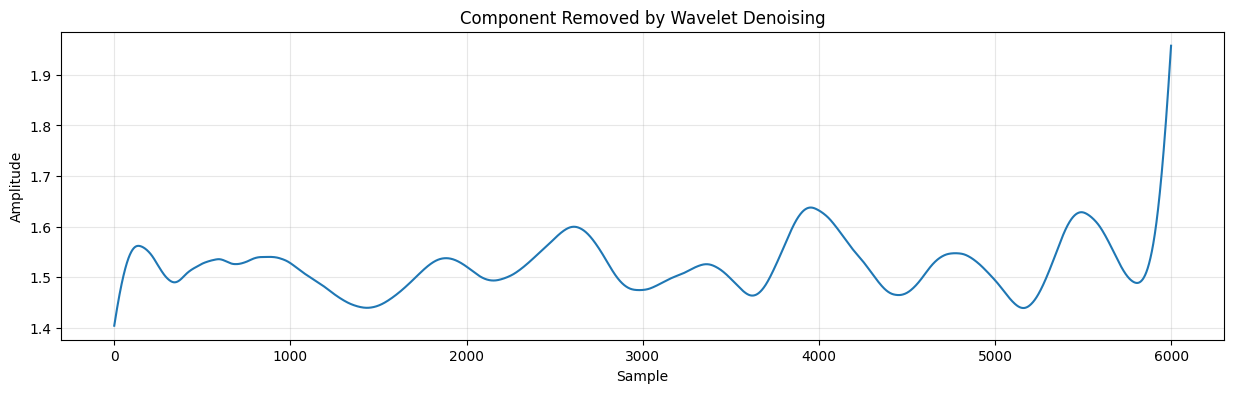

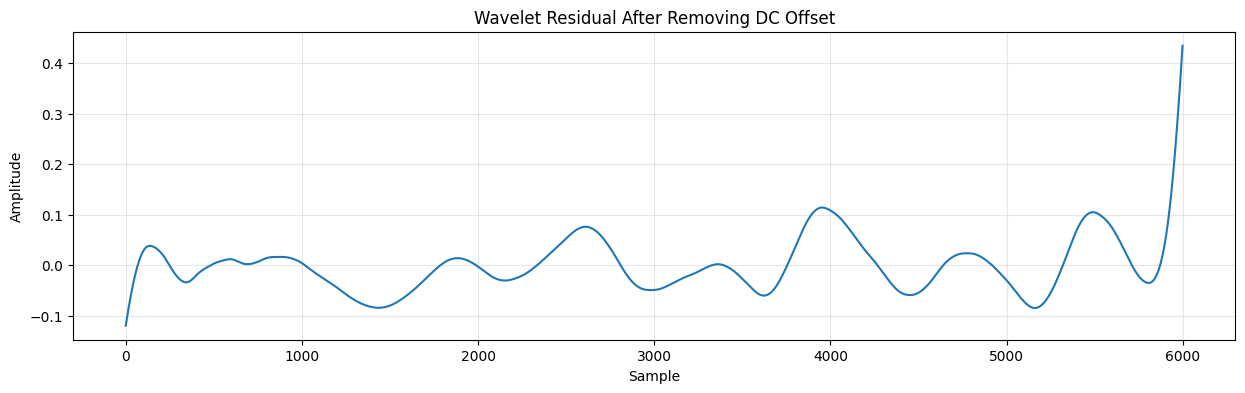

In [12]:
ppg = recording[:, 0]

denoised_ppg = wavelet_denoise_db8(
    ppg,
    wavelet="db8",
    level=8
)

results = analyze_wavelet_denoising(
    ppg,
    denoised_ppg,
    fs=125,
    plot_seconds=30
)

WAVELET DENOISING ANALYSIS

Shape:
Original shape : (6000,)
Denoised shape : (6000,)

Original:
Mean : 1.521038
Std  : 0.633912
Min  : 0.944282
Max  : 3.191593

Denoised:
Mean : -0.001182
Std  : 0.631181
Min  : -0.875619
Max  : 1.741349

Similarity:
Correlation : 0.99060

Residual:
Residual std : 0.086777
Residual / signal std : 13.689%


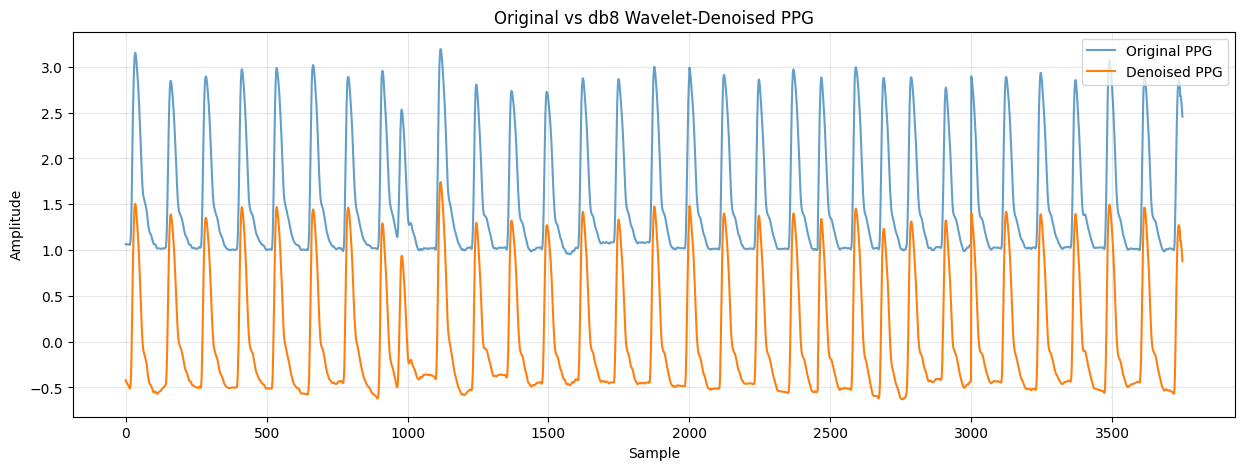

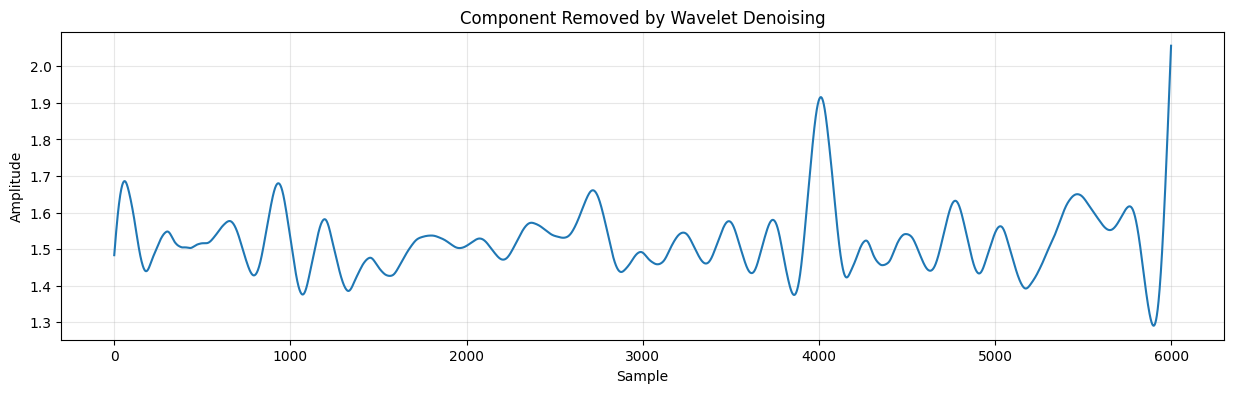

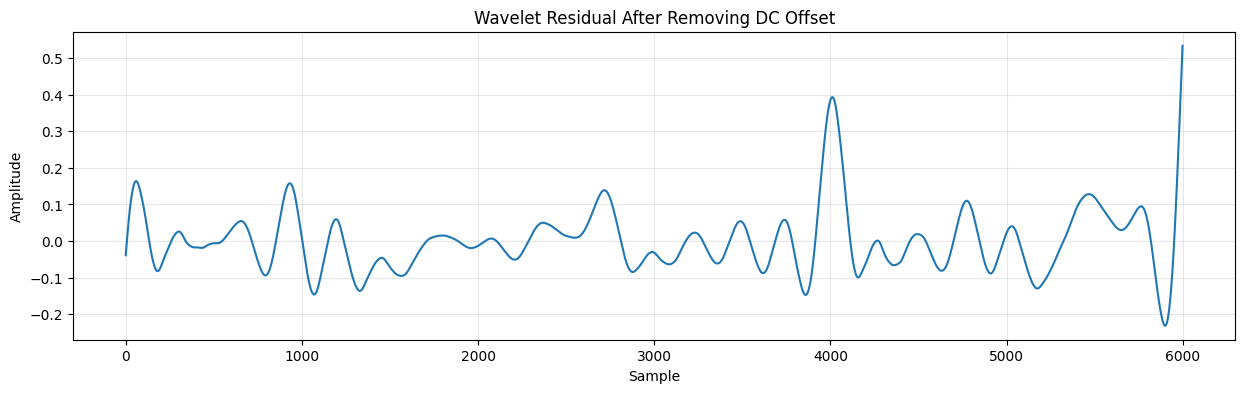

In [13]:
ppg = recording[:, 0]

denoised_ppg = wavelet_denoise_db8(
    ppg,
    wavelet="db8",
    level=7
)

results = analyze_wavelet_denoising(
    ppg,
    denoised_ppg,
    fs=125,
    plot_seconds=30
)

WAVELET DENOISING ANALYSIS

Shape:
Original shape : (6000,)
Denoised shape : (6000,)

Original:
Mean : 1.521038
Std  : 0.633912
Min  : 0.944282
Max  : 3.191593

Denoised:
Mean : -0.001353
Std  : 0.523023
Min  : -1.072863
Max  : 1.551994

Similarity:
Correlation : 0.83187

Residual:
Residual std : 0.351833
Residual / signal std : 55.502%


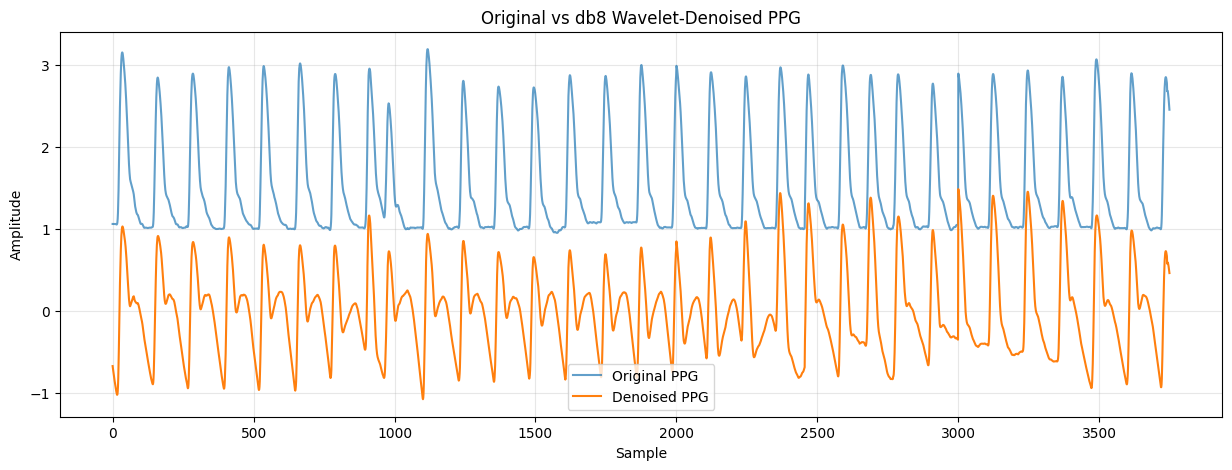

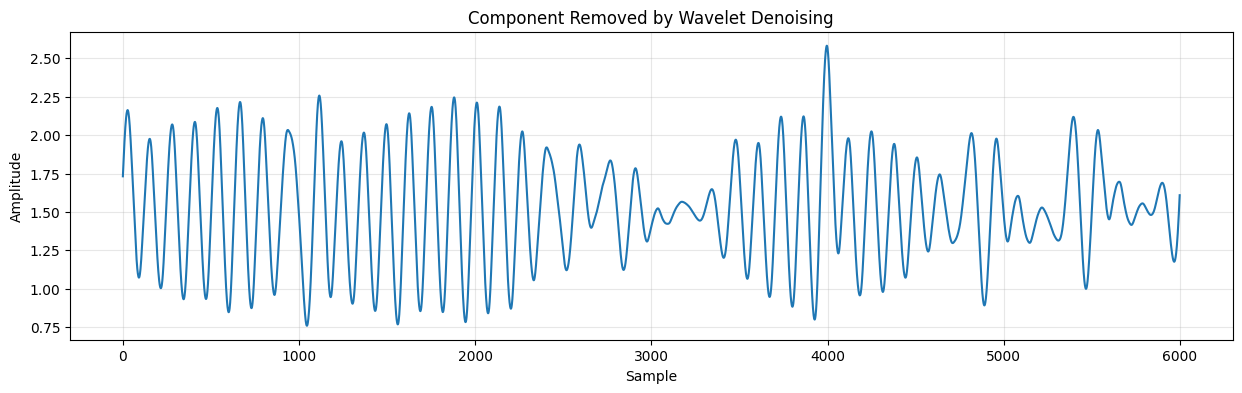

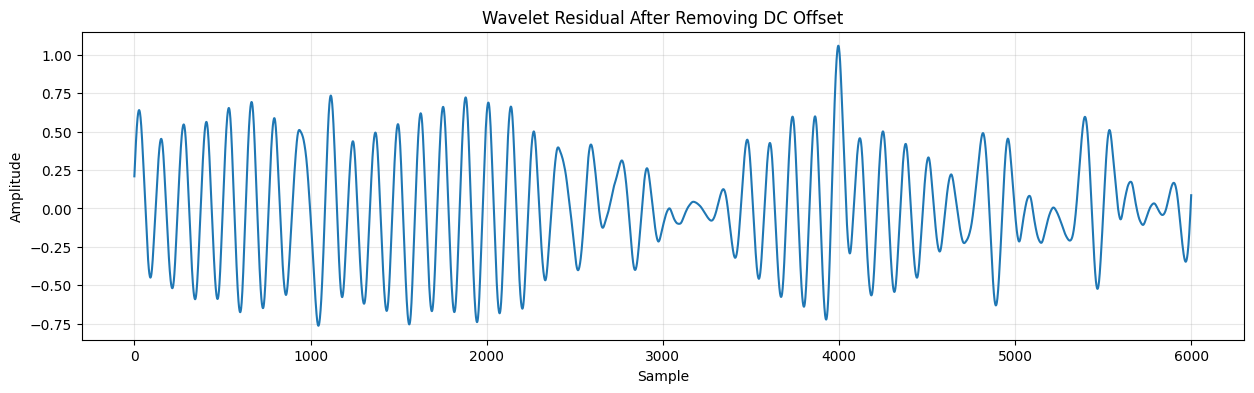

In [14]:
ppg = recording[:, 0]

denoised_ppg = wavelet_denoise_db8(
    ppg,
    wavelet="db8",
    level=6
)

results = analyze_wavelet_denoising(
    ppg,
    denoised_ppg,
    fs=125,
    plot_seconds=30
)

In [ ]:
def remove_A8_D8_from_ppg(
    ppg,
    wavelet="db8",
    level=7
):
    """
    7-level db8 wavelet decomposition.

    Removes:
        A7 : 0 - ~0.Hz
        D7 : ~0.24 - 0.49 Hz

    Keeps:
        D1-D7

    Parameters
    ----------
    ppg : numpy array
        1D PPG signal.

    wavelet : str
        Wavelet name.

    level : int
        Decomposition level. Use 8.

    Returns
    -------
    denoised_ppg : numpy array
        Reconstructed PPG after removing A8 and D8.
    """

    ppg = np.asarray(
        ppg,
        dtype=np.float64
    )

    # -----------------------------------------
    # Wavelet decomposition
    # -----------------------------------------

    coeffs = pywt.wavedec(
        ppg,
        wavelet=wavelet,
        level=level
    )

    # coeffs structure:
    #
    # [A8, D8, D7, D6, D5, D4, D3, D2, D1]

    # -----------------------------------------
    # Remove A8
    # -----------------------------------------

    coeffs[0] = np.zeros_like(
        coeffs[0]
    )

    # -----------------------------------------
    # Remove D8
    # -----------------------------------------

    coeffs[1] = np.zeros_like(
        coeffs[1]
    )



    # -----------------------------------------
    # Reconstruct signal
    # -----------------------------------------

    denoised_ppg = pywt.waverec(
        coeffs,
        wavelet=wavelet
    )

    # waverec can sometimes return
    # one or a few extra samples
    denoised_ppg = denoised_ppg[
        :len(ppg)
    ]

    return denoised_ppg.astype(
        np.float64
    )


def create_wavelet_dataset(
    input_folder,
    output_folder,
    wavelet="db8",
    level=8
):
    """
    Process all four UCI Part files and save them
    in the same HDF5 structure.

    Input:
        Part_1.mat
        Part_2.mat
        Part_3.mat
        Part_4.mat

    Output:
        output_folder/
            Part_1.mat
            Part_2.mat
            Part_3.mat
            Part_4.mat
    """

    # ==================================================
    # Create output folder
    # ==================================================

    os.makedirs(
        output_folder,
        exist_ok=True
    )

    # ==================================================
    # Process Part_1 -> Part_4
    # ==================================================

    for part in range(1, 5):

        input_file = os.path.join(
            input_folder,
            f"Part_{part}.mat"
        )

        output_file = os.path.join(
            output_folder,
            f"Part_{part}.mat"
        )

        print(
            f"\nProcessing Part_{part}.mat"
        )

        # ----------------------------------------------
        # Open original UCI file
        # ----------------------------------------------

        with h5py.File(
            input_file,
            "r"
        ) as f_in:

            dataset = f_in[
                f"Part_{part}"
            ]

            print(
                "Number of recordings:",
                dataset.shape[0]
            )

            # ------------------------------------------
            # Create output HDF5 file
            # ------------------------------------------

            with h5py.File(
                output_file,
                "w"
            ) as f_out:

                # Create same top-level dataset
                # shape as original:
                #
                # (3000, 1)
                #
                # containing HDF5 object references

                output_dataset = f_out.create_dataset(
                    f"Part_{part}",
                    shape=dataset.shape,
                    dtype=h5py.ref_dtype
                )

                # --------------------------------------
                # Process every recording
                # --------------------------------------

                for i in range(
                    dataset.shape[0]
                ):

                    # ==================================
                    # Dereference recording
                    # ==================================

                    ref = dataset[i, 0]

                    recording = f_in[
                        ref
                    ]

                    data = recording[
                        :]

                    # data shape:
                    #
                    # (N, 3)
                    #
                    # PPG | ABP | ECG

                    # ==================================
                    # Extract channels
                    # ==================================

                    ppg = data[:, 0]

                    abp = data[:, 1]

                    ecg = data[:, 2]

                    # ==================================
                    # Wavelet process PPG
                    # ==================================

                    denoised_ppg = (
                        remove_A8_D8_from_ppg(
                            ppg,
                            wavelet=wavelet,
                            level=level
                        )
                    )

                    # ==================================
                    # Reconstruct complete recording
                    # ==================================

                    processed_data = np.column_stack(
                        (
                            denoised_ppg,
                            abp,
                            ecg
                        )
                    )

                    # ==================================
                    # Store recording
                    # ==================================

                    recording_name = (
                        f"recording_{i}"
                    )

                    output_recording = (
                        f_out.create_dataset(
                            recording_name,
                            data=processed_data,
                            dtype=np.float64
                        )
                    )

                    # ==================================
                    # Store reference
                    # ==================================

                    output_dataset[
                        i, 0
                    ] = output_recording.ref

                    # ==================================
                    # Progress
                    # ==================================

                    if (
                        (i + 1) % 100 == 0
                        or
                        i == 0
                        or
                        i == dataset.shape[0] - 1
                    ):

                        print(
                            f"  Recording "
                            f"{i + 1}/"
                            f"{dataset.shape[0]}"
                        )

        print(
            f"Saved: {output_file}"
        )

    print(
        "\n========================================"
    )

    print(
        "Wavelet preprocessing complete!"
    )

    print(
        "Output folder:",
        output_folder
    )

In [26]:
DATA_PATH = "../UCI/data"
WAVELET_PATH = "../UCI/wavelets_data"

In [27]:
create_wavelet_dataset(
    input_folder=DATA_PATH,
    output_folder=WAVELET_PATH,
    wavelet="db8",
    level=8
)


Processing Part_1.mat


FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = '../UCI/data/Part_1.mat', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

In [ ]:
from scipy.signal import find_peaks

peaks_original, _ = find_peaks(
    ppg,
    distance=50
)

peaks_denoised, _ = find_peaks(
    denoised_ppg,
    distance=50
)

print(
    "Original peaks:",
    len(peaks_original)
)

print(
    "Denoised peaks:",
    len(peaks_denoised)
)

Original peaks: 994
Denoised peaks: 993


In [ ]:
noise = ppg - denoised_ppg

print("Noise mean:", np.mean(noise))
print("Noise std :", np.std(noise))

print(
    "Noise / signal std ratio:",
    np.std(noise) / np.std(ppg)
)

Noise mean: 1.8396674509497535
Noise std : 0.1547239242450104
Noise / signal std ratio: 0.24482551284632761


In [ ]:
ppg_centered = ppg - np.mean(ppg)

denoised_centered = (
    denoised_ppg - np.mean(denoised_ppg)
)

residual = (
    ppg_centered - denoised_centered
)

print("Residual mean:", np.mean(residual))
print("Residual std :", np.std(residual))

print(
    "Residual / signal std ratio:",
    np.std(residual) / np.std(ppg_centered)
)

Residual mean: -5.951131956480747e-09
Residual std : 0.1547239243476929
Residual / signal std ratio: 0.24482551300880598


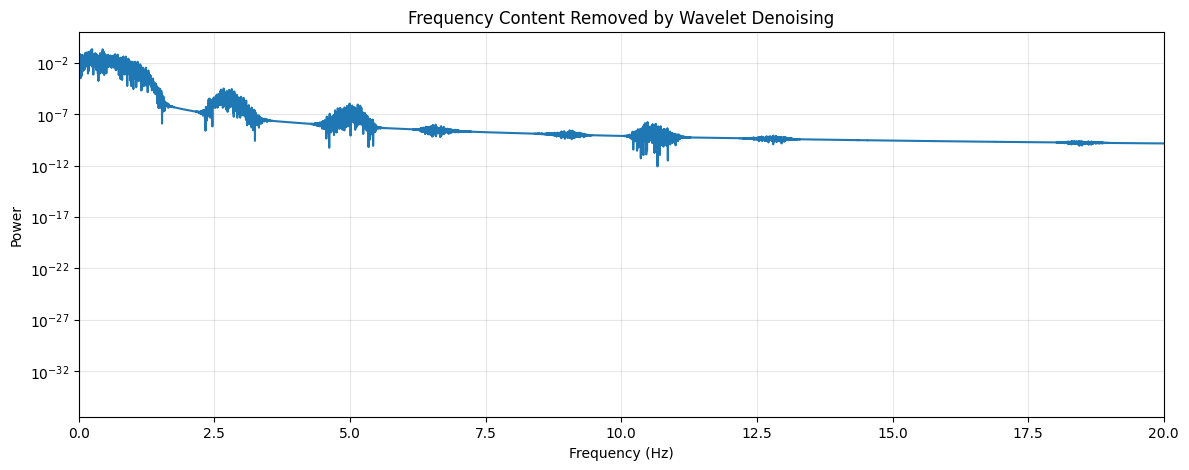

In [ ]:
from scipy.signal import periodogram

fs = 125

f, P = periodogram(
    residual,
    fs=fs
)

plt.figure(figsize=(14, 5))

plt.semilogy(
    f,
    P
)

plt.xlim(0, 20)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Power")
plt.title("Frequency Content Removed by Wavelet Denoising")

plt.grid(alpha=0.3)

plt.show()